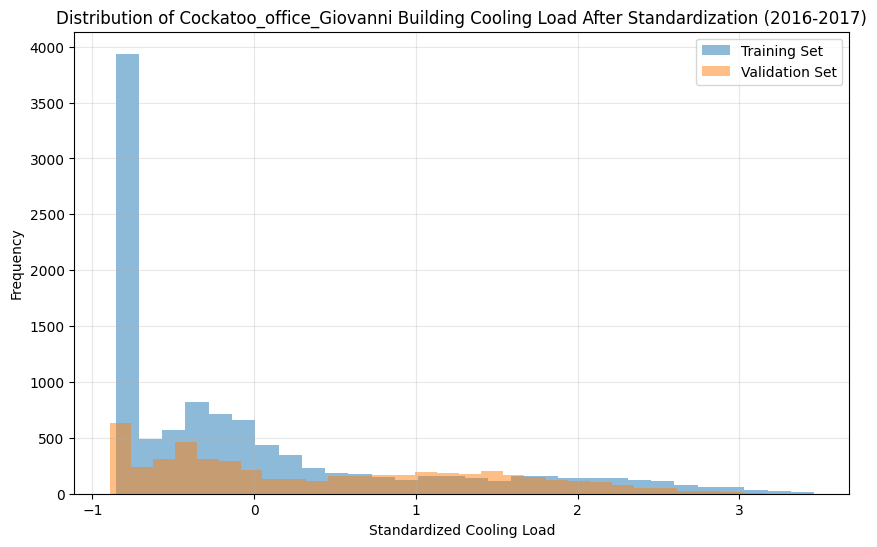

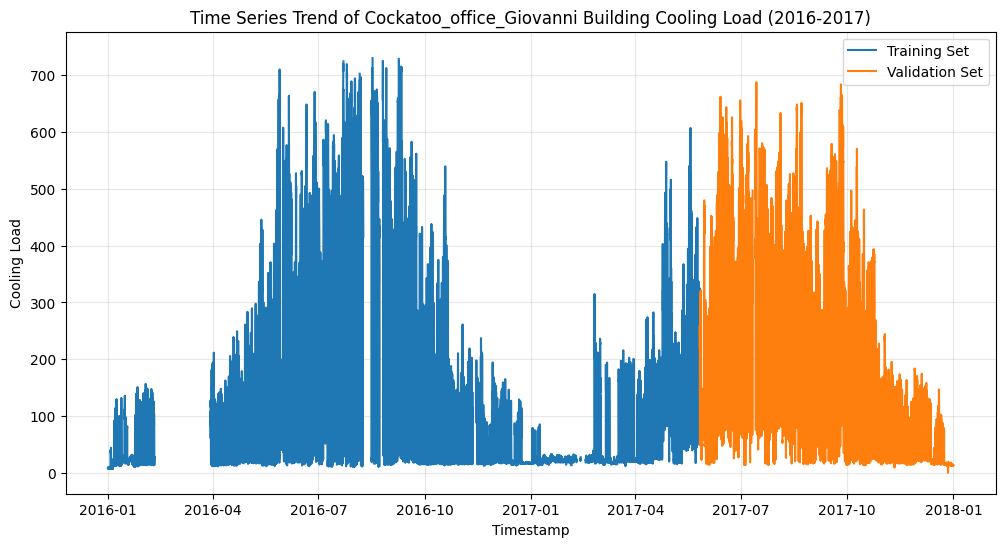

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

# 加载数据
chilledwater = pd.read_csv("C:/Users/lenovo/Desktop/chilledwater_cleaned1.csv")

# 指定要分析的建筑ID 1.Bull_office_Myron  2.Fox_office_Essie  3.Hog_office_Garrett  4.Eagle_office_Sheree  5.Cockatoo_office_Giovanni
one_building_id = 'Cockatoo_office_Giovanni'

# 提取特定建筑的冷负荷数据
building_cooling_load = chilledwater[[one_building_id]].copy()
building_cooling_load.columns = ['Building cooling load']

# 将时间戳转换为 datetime 类型
building_cooling_load['timestamp'] = pd.to_datetime(chilledwater['timestamp'])
building_cooling_load.set_index('timestamp', inplace=True)

# 选择2016年和2017年的完整数据
start_date_2016 = '2016-01-01 00:00:00'
end_date_2017 = '2017-12-31 23:59:59'
two_years = building_cooling_load.loc[start_date_2016:end_date_2017]

# 按时间序列划分训练集和验证集
train_size = 0.7  # 训练集占70%
val_size = 0.2   # 验证集占30%

# 确保数据按时间顺序排列
two_years = two_years.sort_index()

# 划分训练集和验证集
split_index = int(len(two_years) * train_size)
Y_train = two_years.iloc[:split_index]
Y_val = two_years.iloc[split_index:]

# 对目标变量进行标准化
y_scaler = StandardScaler()
Y_train_scaled = y_scaler.fit_transform(Y_train)
Y_val_scaled = y_scaler.transform(Y_val)

# 将标准化后的数据转换为 DataFrame
Y_train_scaled = pd.DataFrame(Y_train_scaled, columns=Y_train.columns, index=Y_train.index)
Y_val_scaled = pd.DataFrame(Y_val_scaled, columns=Y_val.columns, index=Y_val.index)

# 绘制目标变量的分布图
plt.figure(figsize=(10, 6))
plt.hist(Y_train_scaled, bins=30, alpha=0.5, label='Training Set')
plt.hist(Y_val_scaled, bins=30, alpha=0.5, label='Validation Set')
plt.legend()
plt.title(f'Distribution of {one_building_id} Building Cooling Load After Standardization (2016-2017)')
plt.xlabel('Standardized Cooling Load')
plt.ylabel('Frequency')
plt.grid(True, alpha=0.3)
plt.show()

# 绘制时间序列趋势图
plt.figure(figsize=(12, 6))
plt.plot(Y_train.index, Y_train, label='Training Set')
plt.plot(Y_val.index, Y_val, label='Validation Set')
plt.legend()
plt.title(f'Time Series Trend of {one_building_id} Building Cooling Load (2016-2017)')
plt.xlabel('Timestamp')
plt.ylabel('Cooling Load')
plt.grid(True, alpha=0.3)
plt.show()